In [55]:
# Script to plot the lat, lon, outer surface Br and date saved from the pfss files via
# convert_pfss_files.ipynb
# 
# These are the DeRosa ones that are part of the sswidl pfss package
# https://hesperia.gsfc.nasa.gov/ssw/packages/pfss/
# https://www.lmsal.com/~derosa/pfsspack/
# 
# Original file urls are like:
# https://www.lmsal.com/solarsoft/archive/ssw/pfss_links_v2/Bfield_20030607_120400.h5
# 
# 6 Oct 2026 IGH

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy

plt.rcParams["font.size"] = 16

In [57]:
main_dir="br_data/"
fname="brout_20030607T120400.npz"
year=fname[6:10]
month=fname[10:12]
sub_dir=  year+"/"+ month+"/"

# load in the file
with np.load(main_dir+sub_dir+fname) as f:
        lat, lon, br_out, date = f["lat"], f["lon"], f["br_out"], astropy.time.Time(str(f["date"]))


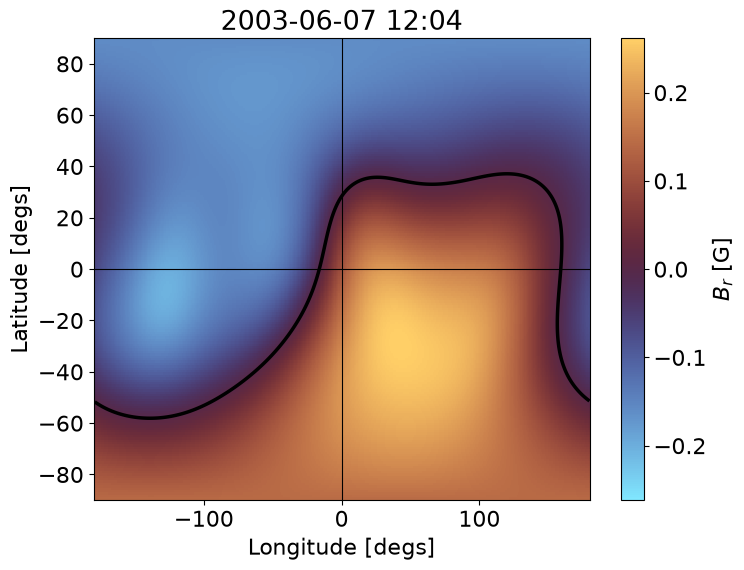

In [58]:
# Plot the outer surface radial magnetic field
fig, ax = plt.subplots(figsize=(8, 6))

# Make sure the range has is symmertical
vmax=np.max(np.abs(br_out))

im=ax.pcolormesh(lon, lat, br_out,cmap='managua_r',vmin=-1*vmax,vmax=vmax)
ax.contour(lon, lat, br_out, levels=[0], colors="k", linewidths=2.5)  # polarity inversion line
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.set(xlim=(-180, 180), ylim=(-90, 90), xlabel="Longitude [degs]", ylabel="Latitude [degs]",
        title=date.iso[:16])
fig.colorbar(im, label=r"$B_r$ [G]")
plt.show()

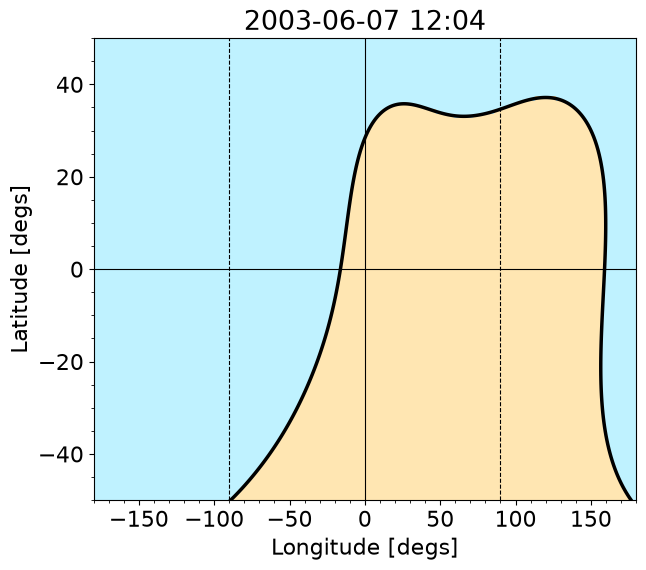

In [62]:
# Plot again but only show as regions of + or -
fig, ax = plt.subplots(figsize=(7, 6))
im=ax.pcolormesh(lon, lat, np.sign(br_out),cmap='managua_r',vmin=-1,vmax=1,alpha=0.5)
ax.contour(lon, lat, br_out, levels=[0], colors="k", linewidths=2.5)  # polarity inversion line
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.axvline(-90, color="k", lw=0.8,ls='--')
ax.axvline(90, color="k", lw=0.8,ls='--')

ax.set(xlim=(-180, 180), ylim=(-50, 50), xlabel="Longitude [degs]", ylabel="Latitude [degs]",
        title=date.iso[:16])
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.minorticks_on()
plt.show()